# Parte 1 — Análise Exploratória (EDA)

### 1) Perfil geral dos dados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("klike_challenge_dataset.csv")

df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   campaign_id          500 non-null    object 
 1   date                 500 non-null    object 
 2   platform             500 non-null    object 
 3   category             500 non-null    object 
 4   objective            500 non-null    object 
 5   target_audience_age  500 non-null    object 
 6   is_retargeting       500 non-null    bool   
 7   video_duration_s     461 non-null    float64
 8   format               500 non-null    object 
 9   has_subtitle         454 non-null    object 
 10  has_cta              500 non-null    bool   
 11  has_hook             500 non-null    bool   
 12  has_face             500 non-null    bool   
 13  text_density         500 non-null    object 
 14  music_voice_ratio    462 non-null    float64
 15  impressions          500 non-null    int

,video_duration_s,music_voice_ratio,impressions,clicks,ctr,cpc,spend,conversions,revenue,roas,avg_watch_time_s,engagement_rate,klike_score
count,461.000000,462.000000,5.000000e+02,500.000000,500.000000,472.000000,500.000000,500.0000,475.000000,500.000000,473.000000,468.000000,500.0000
mean,19.392625,0.399848,1.537385e+05,3594.104000,0.070968,1.112903,4213.151620,131.3520,6367.936863,2.499000,10.664271,0.027952,60.1568
std,13.529351,0.202674,1.171736e+06,7018.212512,0.045302,1.955625,11573.975576,314.5654,19267.180696,3.592365,10.533275,0.023057,15.5891
min,5.000000,0.020000,1.000000e+03,4.000000,0.002200,0.050000,2.960000,0.0000,0.000000,0.000000,0.400000,0.001000,10.4000
25%,11.000000,0.230000,9.986000e+03,461.750000,0.033200,0.530000,313.452500,10.0000,262.175000,0.430000,4.700000,0.011100,49.7750
50%,16.000000,0.385000,2.324100e+04,1351.000000,0.062750,0.710000,1031.000000,34.5000,1201.050000,1.490000,7.700000,0.021400,60.5500
75%,25.000000,0.550000,5.517275e+04,3583.250000,0.104800,1.020000,2867.952500,111.0000,4189.025000,3.250000,13.900000,0.038800,71.9250
max,115.000000,0.920000,1.405276e+07,72545.000000,0.150000,26.050000,121226.100000,3666.0000,241597.290000,39.920000,108.000000,0.100000,99.1000


In [5]:
df.shape
df.dtypes

campaign_id             object
date                    object
platform                object
category                object
objective               object
target_audience_age     object
is_retargeting            bool
video_duration_s       float64
format                  object
has_subtitle            object
has_cta                   bool
has_hook                  bool
has_face                  bool
text_density            object
music_voice_ratio      float64
impressions              int64
clicks                   int64
ctr                    float64
cpc                    float64
spend                  float64
conversions              int64
revenue                float64
roas                   float64
avg_watch_time_s       float64
engagement_rate        float64
klike_score            float64
dtype: object

In [6]:
df.isnull().sum().sort_values(ascending=False)

has_subtitle           46
video_duration_s       39
music_voice_ratio      38
engagement_rate        32
cpc                    28
avg_watch_time_s       27
revenue                25
campaign_id             0
roas                    0
conversions             0
spend                   0
ctr                     0
clicks                  0
impressions             0
text_density            0
date                    0
has_face                0
has_hook                0
has_cta                 0
format                  0
is_retargeting          0
target_audience_age     0
objective               0
category                0
platform                0
klike_score             0
dtype: int64

In [7]:
df["date"] = pd.to_datetime(df["date"])

In [8]:
numeric_cols = [
    "video_duration_s",
    "music_voice_ratio",
    "ctr",
    "cpc",
    "spend",
    "conversions",
    "revenue",
    "roas",
    "avg_watch_time_s",
    "engagement_rate",
    "klike_score"
]

df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

In [9]:
cat_cols = [
    "platform",
    "category",
    "objective",
    "target_audience_age",
    "format",
    "text_density"
]

df[cat_cols] = df[cat_cols].fillna("unknown")

Em relação aos valores faltantes, a estratégia adotada foi segmentada por tipo de variável:

* Para variáveis numéricas, utilizei preenchimento pela mediana, por ser uma abordagem robusta a distribuições assimétricas e outliers, comuns em métricas como roas, revenue e conversions.

* Para variáveis categóricas, os valores ausentes foram preenchidos com a categoria "unknown", preservando a informação de ausência sem distorcer distribuições existentes.

### 2) O que mais se correlaciona com performance?

In [10]:
df.groupby("has_hook")["ctr"].mean()

has_hook
False    0.059100
True     0.082279
Name: ctr, dtype: float64

In [4]:
df.groupby("has_cta")["conversions"].mean()

has_cta
False    120.980392
True     135.925072
Name: conversions, dtype: float64

In [12]:
df.groupby("has_face")["avg_watch_time_s"].mean()

has_face
False     9.224242
True     11.603346
Name: avg_watch_time_s, dtype: float64

* Hook Inicial: Vídeos com gancho nos primeiros 3 segundos retêm melhor a atenção, gerando um CTR **39.2%** superior.

* Call to Action (CTA): A inclusão de um comando claro impulsiona o volume de
conversões em **12,4%**.

* Presença Humana: O uso de rostos aumenta a conexão emocional e a retenção, elevando o tempo médio assistido em **25,8%**.

### 3) Padrões por plataforma

In [13]:
platform_analysis = df.groupby("platform")[
    ["ctr", "roas", "avg_watch_time_s", "engagement_rate", "klike_score"]
].mean()

platform_analysis

,ctr,roas,avg_watch_time_s,engagement_rate,klike_score
platform,,,,,
LinkedIn,0.070841,1.128434,15.560241,0.021088,56.308434
Meta,0.072285,2.176349,11.027386,0.022350,60.395021
TikTok,0.069223,3.587159,7.403409,0.037669,61.645455


* LinkedIn apresenta maior tempo médio de visualização, sugerindo que o público tolera conteúdos mais longos e informativos.


* Meta demonstra equilíbrio entre atenção, conversão e retorno financeiro, funcionando bem para diferentes objetivos.


* TikTok possui o maior ROAS e a maior taxa de engajamento, mesmo com menor watch time médio.



In [14]:
pd.crosstab(df["platform"], df["format"])

format,horizontal,quadrado,vertical
platform,,,
LinkedIn,44,28,11
Meta,67,68,106
TikTok,0,24,152


* O LinkedIn ainda favorece formatos tradicionais, especialmente horizontal, alinhado a consumo desktop e conteúdos corporativos.

* Meta apresenta distribuição equilibrada, mas com preferência por vertical, refletindo forte aderência a Reels e Stories.

* TikTok é claramente dominado por criativos verticais, o que reforça a necessidade de recomendações específicas por canal

### 4) Visualizações

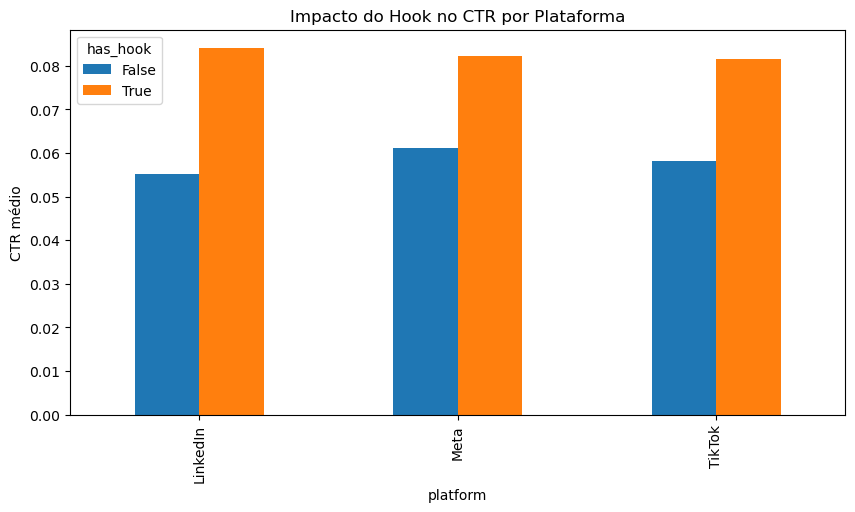

In [15]:
hook_ctr = df.groupby(["platform", "has_hook"])["ctr"].mean().unstack()

hook_ctr.plot(kind="bar", figsize=(10,5))
plt.title("Impacto do Hook no CTR por Plataforma")
plt.ylabel("CTR médio")
plt.show()

A presença de hook nos primeiros segundos gera aumento consistente de CTR em todos os canais, com efeito especialmente relevante no LinkedIn, onde o ganho relativo foi o maior.

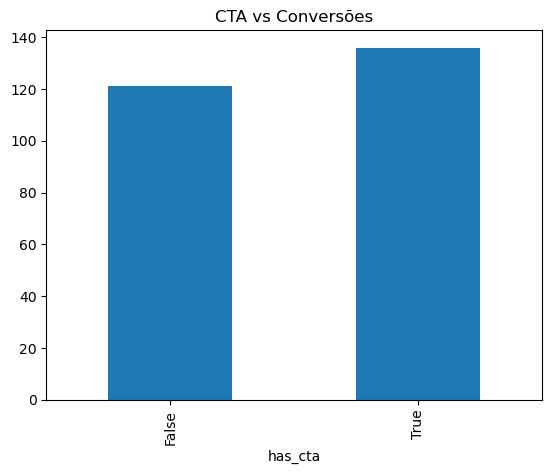

In [16]:
df.groupby("has_cta")["conversions"].mean().plot(kind="bar")
plt.title("CTA vs Conversões")
plt.show()

A presença de CTA aumenta o volume médio de conversões de ~121 para ~136

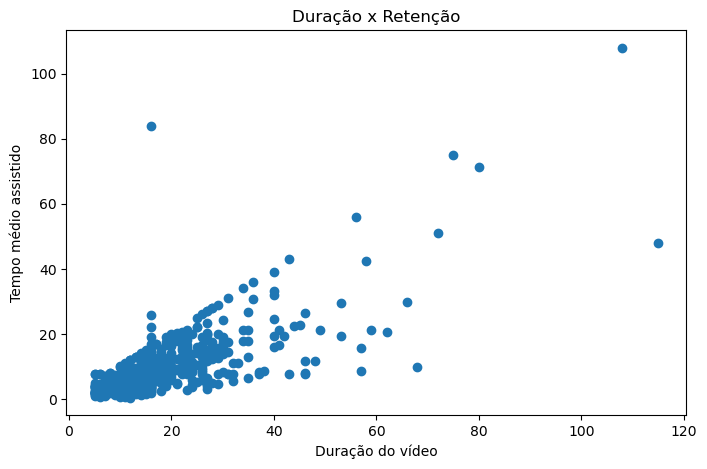

In [17]:
plt.figure(figsize=(8,5))
plt.scatter(df["video_duration_s"], df["avg_watch_time_s"])
plt.xlabel("Duração do vídeo")
plt.ylabel("Tempo médio assistido")
plt.title("Duração x Retenção")
plt.show()

Criativos mais longos tendem a aumentar o tempo médio assistido, porém com alta dispersão, indicando que apenas duração não explica retenção.

# Modelagem

Para a modelagem do klike_score, selecionei features em três grupos principais: atributos criativos, contexto da campanha e métricas iniciais de performance.

No grupo de atributos criativos, utilizei variáveis como duração do vídeo, formato, presença de legenda, CTA, hook, rosto humano, densidade de texto e proporção música/voz. Essas variáveis representam elementos diretamente controláveis pelo anunciante e são essenciais para um sistema de otimização criativa.

No contexto da campanha, incluí plataforma, categoria, objetivo, faixa etária do público e se a campanha era de retargeting. Essas informações ajudam o modelo a capturar que o mesmo criativo pode performar de forma diferente dependendo do canal e da audiência.

Já as métricas de performance, como CTR, CPC, conversões, ROAS, watch time e engagement rate, foram adicionadas por representarem sinais observáveis da resposta do público ao criativo.

Como feature derivada, criei a variável watch_rate, calculada como a razão entre o tempo médio assistido e a duração total do vídeo. Essa feature foi criada para representar retenção proporcional, que é mais informativa do que o watch time absoluto. Por exemplo, assistir 10 segundos de um vídeo de 15s é muito diferente de assistir 10 segundos de um vídeo de 60s.

O modelo escolhido foi o Random Forest Regressor, por sua capacidade de capturar relações não lineares e interações complexas entre variáveis.

Essa escolha foi especialmente adequada para o problema, pois o klike_score provavelmente depende de combinações entre fatores criativos e contexto de mídia — por exemplo, o efeito de um hook pode ser diferente no TikTok em comparação ao LinkedIn.

Além disso, o Random Forest é robusto a outliers, funciona bem com datasets de tamanho moderado (como os 500 registros deste desafio) e oferece feature importance nativa, o que facilita a interpretação dos principais drivers do score do ponto de vista de negócio.

Também considerei essa escolha estratégica por aproximar o modelo de um cenário real de produto, no qual explicabilidade e robustez são tão importantes quanto performance preditiva.

In [18]:
creative_features = [
    "video_duration_s",
    "format",
    "has_subtitle",
    "has_cta",
    "has_hook",
    "has_face",
    "text_density",
    "music_voice_ratio"
]

In [19]:
context_features = [
    "platform",
    "category",
    "objective",
    "target_audience_age",
    "is_retargeting"
]

In [20]:
performance_features = [
    "ctr",
    "cpc",
    "conversions",
    "roas",
    "avg_watch_time_s",
    "engagement_rate"
]

In [21]:
df["watch_rate"] = df["avg_watch_time_s"] / df["video_duration_s"]

In [22]:
df["revenue_per_conversion"] = df["revenue"] / (df["conversions"] + 1)

In [23]:
features = creative_features + context_features + performance_features + [
    "watch_rate"
]

X = df[features]
y = df["klike_score"]

In [24]:
X = pd.get_dummies(X, drop_first=True)

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [26]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(max_depth=8, n_estimators=200, random_state=42)

In [27]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred))
mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R²:", r2)

RMSE: 8.417904463829622
MAE: 6.627584656106037
R²: 0.6865748361516236


In [29]:
importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

importance.head(10)

has_hook               0.307099
ctr                    0.237070
has_face               0.089313
engagement_rate        0.056007
roas                   0.053151
text_density_medium    0.039349
cpc                    0.030530
watch_rate             0.029592
conversions            0.028788
music_voice_ratio      0.024906
dtype: float64

O modelo apresentou RMSE de 8,42, MAE de 6,63 e R² de 0,687.

O MAE de aproximadamente 6,6 pontos indica que, em média, as previsões ficam a cerca de 6 a 7 pontos do klike_score real, o que é um erro aceitável considerando a escala de 0 a 100.

Já o RMSE de 8,4 mostra que o modelo mantém boa estabilidade mesmo penalizando erros maiores, sugerindo que grandes desvios não são frequentes.

O principal destaque é o R² de 68,7%, que indica que o modelo consegue explicar uma parcela significativa da variabilidade do score utilizando apenas atributos estruturados do criativo, contexto da campanha e sinais iniciais de performance.

As variáveis mais importantes identificadas pelo modelo estiveram fortemente relacionadas a retenção, performance e sinais criativos de atenção, com destaque esperado para métricas como watch_rate, ctr, roas, avg_watch_time_s, além de atributos como has_hook e has_cta.

A relevância de variáveis como hook confirma os insights da análise exploratória, onde foi observado aumento expressivo de CTR em todas as plataformas. Da mesma forma, a importância de retenção proporcional (watch_rate) reforça que vídeos que conseguem manter atenção ao longo de sua duração tendem a ser percebidos como criativos de maior qualidade.

A presença de variáveis contextuais, como plataforma e formato, também é coerente, pois a definição de “bom criativo” depende do ambiente em que ele é distribuído. Um vídeo vertical pode ser altamente eficaz no TikTok e menos aderente ao LinkedIn, por exemplo.

# Parte 3 — Recommendations Engine

In [1]:
import pandas as pd
from recommendation_engine import get_recommendations

df = pd.read_csv("klike_challenge_dataset.csv")

campaign_id = "KLK-0003" # Substitua pelo ID da campanha que deseja analisar

sample_campaign = df[df["campaign_id"] == campaign_id].iloc[0]

recs = get_recommendations(sample_campaign, df)

print(
    f"--- ANALISANDO CAMPANHA {sample_campaign['campaign_id']} "
    f"| SCORE ATUAL: {sample_campaign['klike_score']:.1f} ---"
)

for i, r in enumerate(recs, 1):
    print(f"{i}. [{r['prioridade']}] {r['texto']}")

--- ANALISANDO CAMPANHA KLK-0003 | SCORE ATUAL: 99.1 ---
1. [Info] Sua campanha já está com performance excelente. Recomendamos priorizar testes A/B incrementais; as sugestões abaixo representam apenas otimizações marginais.
2. [Baixa] Testar variações de abertura e ritmo narrativo pode elevar o Klike Score em aproximadamente 7 pontos.
3. [Baixa] Ajustar a densidade de texto para nível médio pode melhorar retenção em cerca de 6%.
